
# NB09 — LLM-Governed Autonomous Quantitative Research System

## From deterministic orchestration to a real cognitive control plane

NB08 achieved a major integration milestone: real quantitative models, strategy construction, portfolio testing, cost stress, governance, provenance, independent risk review, and a stateful mission runner all operated inside one bounded research architecture. But its *meta-agent* still interpreted objectives and assembled plans through deterministic Python logic. Keyword matching and registry rules made the system dynamic, but no language model was actually thinking about the mission.

NB09 closes that gap.

A real LLM is now introduced into the architecture as a **bounded cognitive control plane**. The LLM is allowed to interpret a natural-language research objective, select among pre-approved model tools, choose rule-based strategies and portfolio methods, and explain why it proposes that research design. After the quantitative experiment finishes, a second LLM call acts as a research critic: it interprets the scorecards, highlights weaknesses, and proposes follow-up experiments.

The LLM does **not** calculate returns, fit models, alter risk limits, approve a strategy, deploy code, or place orders. Those remain deterministic, governed functions. This separation is essential:

**language model = interpretation, planning, synthesis, challenge**  
**quantitative tools = estimation, prediction, backtesting, portfolio mathematics**  
**policy layer = authority, permissions, limits, promotion gates**  
**human = material decision owner**

The execution chain is:

**Natural-language mission → deterministic admission gate → LLM planning → schema validation → governed plan compiler → quantitative tools → deterministic champion rule → independent risk → LLM research critique → human handoff**

This is the first notebook in the sequence in which the autonomous architecture truly contains an LLM in the operational loop.



## 0. Colab setup and API key

This notebook uses the OpenAI Responses API. In Google Colab, store your API key in **Secrets** under the name:

`OPENAI_API_KEY`

Do not paste the key directly into the notebook.

The default model is `gpt-5.6-terra`. You can override it by setting the environment variable `OPENAI_MODEL`.

The LLM API is the only newly permitted external network dependency. Market-data downloads, brokerage connections, live orders, deployment, and self-approval remain prohibited.


In [ ]:

%pip install -q -U openai


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.7/41.7 kB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 24.9 MB/s eta 0:00:00


In [ ]:

from __future__ import annotations

from copy import deepcopy
from pathlib import Path
from datetime import datetime, timezone
import hashlib
import json
import os
import re

import numpy as np
import pandas as pd

from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import accuracy_score, balanced_accuracy_score, brier_score_loss
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

from openai import OpenAI

SYSTEM_VERSION = "0.9.0-llm-governed-research"
NB08_SOURCE_SHA256 = "c12847d7352d9ded275eeb721ee6a9c9f3a6ae07c8754d075b3e425af68bad79"

SYSTEM_BOUNDARY = {
    "asset_class": "synthetic_equities",
    "network": {
        "openai_llm_api": "allow",
        "market_data": "deny",
        "brokerage": "deny",
    },
    "live_orders": "deny",
    "self_approval": "deny",
    "deployment": "deny",
    "human_approval_required": [
        "strategy_promotion",
        "risk_override",
        "deployment",
        "live_execution",
    ],
}

OPENAI_MODEL = os.getenv("OPENAI_MODEL", "gpt-5.6-terra")
PLANNER_PROMPT_VERSION = "NB09_PLANNER_V1"
CRITIC_PROMPT_VERSION = "NB09_CRITIC_V1"


def canonical_json(value):
    return json.dumps(value, sort_keys=True, separators=(",", ":"), default=str)


def stable_hash(value):
    return hashlib.sha256(canonical_json(value).encode("utf-8")).hexdigest()


def load_openai_api_key():
    key = os.getenv("OPENAI_API_KEY")
    if key:
        return key
    try:
        from google.colab import userdata
        return userdata.get("OPENAI_API_KEY")
    except Exception:
        return None


def get_openai_client():
    key = load_openai_api_key()
    if not key:
        raise RuntimeError(
            "OPENAI_API_KEY not found. In Colab, add it to Secrets, "
            "then rerun this cell. Do not paste the key into notebook code."
        )
    return OpenAI(api_key=key)


def append_audit(context, action, payload):
    previous_hash = context["audit"][-1]["event_hash"] if context["audit"] else "GENESIS"
    event = {
        "sequence": len(context["audit"]) + 1,
        "mission_id": context["spec"].get("mission_id", "UNKNOWN"),
        "state": context["state"],
        "action": action,
        "payload_hash": stable_hash(payload),
        "previous_hash": previous_hash,
        "timestamp_utc": datetime.now(timezone.utc).isoformat(),
    }
    event["event_hash"] = stable_hash(event)
    context["audit"].append(event)
    return event


def verify_audit_chain(events):
    previous_hash = "GENESIS"
    for sequence, event in enumerate(events, start=1):
        body = {key: value for key, value in event.items() if key != "event_hash"}
        if event["sequence"] != sequence or event["previous_hash"] != previous_hash:
            return False
        if event["event_hash"] != stable_hash(body):
            return False
        previous_hash = event["event_hash"]
    return True


assert SYSTEM_BOUNDARY["network"]["brokerage"] == "deny"
assert SYSTEM_BOUNDARY["live_orders"] == "deny"
assert SYSTEM_BOUNDARY["self_approval"] == "deny"
print("NB09 environment and research-only constitution PASS")
print("LLM model:", OPENAI_MODEL)
print("NB08 source hash:", NB08_SOURCE_SHA256[:16] + "...")


NB09 environment and research-only constitution PASS
LLM model: gpt-5.6-terra
NB08 source hash: c12847d7352d9ded...



## 1. Deterministic synthetic market and point-in-time features

The LLM never manufactures market observations. We preserve NB08's deterministic synthetic-equity substrate so that the only new source of nondeterminism is the cognitive planning layer, not the data-generating process.


In [ ]:
SECTORS = ["Technology", "Financials", "Healthcare", "Industrials", "Consumer"]
REGIME_PARAMETERS = {
    "calm": {"drift": 0.0002, "vol": 0.006, "spread": 5.0, "volume": 1.00},
    "trend": {"drift": 0.0007, "vol": 0.008, "spread": 6.0, "volume": 1.10},
    "crisis": {"drift": -0.0016, "vol": 0.020, "spread": 18.0, "volume": 1.70},
    "recovery": {"drift": 0.0011, "vol": 0.012, "spread": 9.0, "volume": 1.35},
}


def regime_for_day(index, total_days):
    fraction = index / total_days
    if fraction < 0.28:
        return "calm"
    if fraction < 0.52:
        return "trend"
    if fraction < 0.67:
        return "crisis"
    if fraction < 0.82:
        return "recovery"
    return "calm"


def generate_synthetic_equity_market(seed=42, n_assets=30, n_days=720):
    rng = np.random.default_rng(seed)
    dates = pd.bdate_range("2022-01-03", periods=n_days)
    sectors = np.array([SECTORS[index % len(SECTORS)] for index in range(n_assets)])
    tickers = np.array([f"SYN{index + 1:02d}" for index in range(n_assets)])
    returns = np.zeros((n_days, n_assets))
    volume = np.zeros_like(returns)
    spread = np.zeros_like(returns)
    regimes = []
    asset_alpha = rng.normal(0, 0.00010, n_assets)

    for day in range(n_days):
        regime = regime_for_day(day, n_days)
        regimes.append(regime)
        params = REGIME_PARAMETERS[regime]
        market = rng.normal(params["drift"], params["vol"])
        sector_factor = {sector: rng.normal(0, params["vol"] * 0.35) for sector in SECTORS}
        previous = returns[day - 1] if day else np.zeros(n_assets)
        for asset in range(n_assets):
            continuation = 0.12 * previous[asset] if regime in {"trend", "recovery"} else -0.05 * previous[asset]
            shock = rng.normal(0, params["vol"] * 0.75)
            returns[day, asset] = market + sector_factor[sectors[asset]] + continuation + asset_alpha[asset] + shock
            volume[day, asset] = rng.lognormal(13.2, 0.35) * params["volume"]
            spread[day, asset] = max(1.0, params["spread"] * rng.lognormal(0, 0.18))

    prices = 100 * np.exp(np.cumsum(np.clip(returns, -0.20, 0.20), axis=0))
    records = []
    for day, date in enumerate(dates):
        for asset in range(n_assets):
            records.append({
                "date": date,
                "instrument_id": asset + 1,
                "ticker": tickers[asset],
                "sector": sectors[asset],
                "regime": regimes[day],
                "close": float(prices[day, asset]),
                "volume": int(volume[day, asset]),
                "spread_bps": float(spread[day, asset]),
            })
    frame = pd.DataFrame(records).sort_values(["instrument_id", "date"]).reset_index(drop=True)
    manifest = {
        "dataset_id": "NB09_SYNTHETIC_EQUITIES_V1",
        "seed": seed,
        "assets": n_assets,
        "days": n_days,
        "rows": len(frame),
        "sectors": sorted(frame["sector"].unique()),
        "regimes": sorted(frame["regime"].unique()),
        "content_hash": stable_hash(frame.round(8).to_dict("records")),
    }
    return frame, manifest


MARKET, DATASET_MANIFEST = generate_synthetic_equity_market()
assert len(MARKET) == 30 * 720
assert set(MARKET["sector"]) == set(SECTORS)
assert set(MARKET["regime"]) == set(REGIME_PARAMETERS)
print("deterministic multi-sector, multi-regime synthetic-equity substrate PASS")

deterministic multi-sector, multi-regime synthetic-equity substrate PASS


In [ ]:
FEATURES = ["return_1", "momentum_5", "momentum_20", "volatility_20", "volume_z20", "spread_bps"]


def build_point_in_time_features(market):
    data = market.sort_values(["instrument_id", "date"]).copy()
    grouped = data.groupby("instrument_id", group_keys=False)
    data["return_1"] = grouped["close"].pct_change()
    data["momentum_5"] = grouped["close"].pct_change(5)
    data["momentum_20"] = grouped["close"].pct_change(20)
    data["volatility_20"] = grouped["return_1"].transform(lambda values: values.rolling(20).std())
    log_volume = np.log1p(data["volume"])
    rolling_mean = log_volume.groupby(data["instrument_id"]).transform(lambda values: values.rolling(20).mean())
    rolling_std = log_volume.groupby(data["instrument_id"]).transform(lambda values: values.rolling(20).std())
    data["volume_z20"] = (log_volume - rolling_mean) / rolling_std
    data["forward_return_1"] = grouped["close"].pct_change().shift(-1)
    data["label_up"] = (data["forward_return_1"] > 0).astype(int)
    return data.dropna(subset=FEATURES + ["forward_return_1"]).reset_index(drop=True)


def chronological_split(data):
    dates = np.array(sorted(data["date"].unique()))
    train_end = int(0.60 * len(dates))
    validation_end = int(0.80 * len(dates))
    split = {
        "train": data[data["date"].isin(dates[:train_end])].copy().reset_index(drop=True),
        "validation": data[data["date"].isin(dates[train_end:validation_end])].copy().reset_index(drop=True),
        "test": data[data["date"].isin(dates[validation_end:])].copy().reset_index(drop=True),
    }
    assert split["train"]["date"].max() < split["validation"]["date"].min()
    assert split["validation"]["date"].max() < split["test"]["date"].min()
    return split


FEATURE_DATA = build_point_in_time_features(MARKET)
SPLIT = chronological_split(FEATURE_DATA)
FEATURE_MANIFEST = {
    "feature_names": FEATURES,
    "rows": len(FEATURE_DATA),
    "train_rows": len(SPLIT["train"]),
    "validation_rows": len(SPLIT["validation"]),
    "test_rows": len(SPLIT["test"]),
    "point_in_time": True,
    "chronological_non_overlap": True,
    "content_hash": stable_hash(FEATURE_DATA.round(8).to_dict("records")),
}
assert np.isfinite(FEATURE_DATA[FEATURES].to_numpy()).all()
print("point-in-time features and chronological train-validation-test partitions PASS")

point-in-time features and chronological train-validation-test partitions PASS



## 2. Executable quantitative tools and governed agent registry

The model tools remain real scikit-learn estimators. The important change is that the LLM will now receive a *catalogue* of these capabilities and decide which approved tools are relevant to the mission.

The LLM does not receive Python callables, credentials, brokerage access, or arbitrary code execution. It sees only tool identities, descriptions, constraints, and schemas.


In [ ]:

def logistic_factory(seed):
    return Pipeline([
        ("scale", StandardScaler()),
        ("model", LogisticRegression(max_iter=1000, random_state=seed)),
    ])


def knn_factory(seed):
    return Pipeline([
        ("scale", StandardScaler()),
        ("model", KNeighborsClassifier(n_neighbors=25, weights="distance")),
    ])


def random_forest_factory(seed):
    return RandomForestClassifier(
        n_estimators=80,
        max_depth=5,
        min_samples_leaf=20,
        random_state=seed,
        n_jobs=1,
    )


def neural_network_factory(seed):
    return Pipeline([
        ("scale", StandardScaler()),
        ("model", MLPClassifier(
            hidden_layer_sizes=(12,),
            max_iter=140,
            early_stopping=True,
            random_state=seed,
        )),
    ])


def linear_regression_factory(seed):
    return Pipeline([
        ("scale", StandardScaler()),
        ("model", LinearRegression()),
    ])


MODEL_FACTORIES = {
    "logistic_regression_trainer": logistic_factory,
    "knn_model_trainer": knn_factory,
    "random_forest_trainer": random_forest_factory,
    "bounded_neural_network_trainer": neural_network_factory,
    "linear_regression_trainer": linear_regression_factory,
}

MODEL_REGISTRY = {
    "logistic_regression_trainer": {
        "model_id": "logistic",
        "kind": "classifier",
        "family": "linear",
        "status": "validated",
        "scope": "synthetic_equities",
        "live_authority": False,
    },
    "knn_model_trainer": {
        "model_id": "knn",
        "kind": "classifier",
        "family": "instance_based",
        "status": "validated",
        "scope": "synthetic_equities",
        "live_authority": False,
    },
    "random_forest_trainer": {
        "model_id": "random_forest",
        "kind": "classifier",
        "family": "ensemble",
        "status": "validated",
        "scope": "synthetic_equities",
        "live_authority": False,
    },
    "bounded_neural_network_trainer": {
        "model_id": "bounded_mlp",
        "kind": "classifier",
        "family": "neural",
        "status": "validated",
        "scope": "synthetic_equities",
        "live_authority": False,
    },
    "linear_regression_trainer": {
        "model_id": "linear_regression",
        "kind": "regressor",
        "family": "linear",
        "status": "validated",
        "scope": "synthetic_equities",
        "live_authority": False,
    },
}

RULE_STRATEGIES = [
    "trend_momentum",
    "cross_sectional_momentum",
    "mean_reversion",
    "regime_aware",
]

PORTFOLIO_REGISTRY = {
    "equal_weight": {"status": "validated"},
    "inverse_vol": {"status": "validated"},
    "vol_target": {"status": "validated"},
    "robust_mean_variance": {"status": "validated"},
}

TOOL_DESCRIPTIONS = {
    "logistic_regression_trainer":
        "Scaled logistic classifier for directional next-period prediction.",
    "knn_model_trainer":
        "Distance-weighted K-nearest-neighbors classifier; nonlinear and instance based.",
    "random_forest_trainer":
        "Bounded-depth random forest classifier capturing nonlinear interactions.",
    "bounded_neural_network_trainer":
        "Small regularized MLP classifier with early stopping.",
    "linear_regression_trainer":
        "Linear return regressor converted to a bounded directional score.",
}

TOOL_REGISTRY = {
    **{
        tool_id: {
            **spec,
            "capability": "model_development",
            "callable": True,
        }
        for tool_id, spec in MODEL_REGISTRY.items()
    },
    "point_in_time_feature_builder": {
        "capability": "data_research",
        "status": "validated",
        "scope": "synthetic_equities",
        "live_authority": False,
        "callable": True,
    },
    "baseline_suite": {
        "capability": "model_benchmarking",
        "status": "validated",
        "scope": "synthetic_equities",
        "live_authority": False,
        "callable": True,
    },
    "model_comparison_engine": {
        "capability": "model_comparison",
        "status": "validated",
        "scope": "synthetic_equities",
        "live_authority": False,
        "callable": True,
    },
    "strategy_factory": {
        "capability": "strategy_design",
        "status": "validated",
        "scope": "synthetic_equities",
        "live_authority": False,
        "callable": True,
    },
    "portfolio_backtest_grid": {
        "capability": "backtesting",
        "status": "validated",
        "scope": "synthetic_equities",
        "live_authority": False,
        "callable": True,
    },
    "research_champion_selector": {
        "capability": "research_selection",
        "status": "validated",
        "scope": "synthetic_equities",
        "live_authority": False,
        "callable": True,
    },
    "independent_risk_engine": {
        "capability": "risk_review",
        "status": "validated",
        "scope": "synthetic_equities",
        "live_authority": False,
        "callable": True,
    },
    "llm_mission_planner": {
        "capability": "cognitive_planning",
        "status": "validated",
        "scope": "synthetic_equities",
        "live_authority": False,
        "callable": True,
        "network": "openai_llm_api",
    },
    "llm_research_critic": {
        "capability": "research_synthesis",
        "status": "validated",
        "scope": "synthetic_equities",
        "live_authority": False,
        "callable": True,
        "network": "openai_llm_api",
    },
    "audit_bundle_builder": {
        "capability": "audit_bundle",
        "status": "validated",
        "scope": "synthetic_equities",
        "live_authority": False,
        "callable": True,
    },
}

AGENT_REGISTRY = {
    "meta_research_agent": {
        "constellation": "control_plane",
        "allowed_tools": {"llm_mission_planner"},
    },
    "research_analyst": {
        "constellation": "research_team",
        "allowed_tools": {"point_in_time_feature_builder"},
    },
    "data_scientist": {
        "constellation": "research_team",
        "allowed_tools": set(MODEL_REGISTRY) | {"baseline_suite"},
    },
    "experiment_designer": {
        "constellation": "research_team",
        "allowed_tools": {"model_comparison_engine", "portfolio_backtest_grid"},
    },
    "strategy_designer": {
        "constellation": "strategy_team",
        "allowed_tools": {"strategy_factory"},
    },
    "portfolio_constructor": {
        "constellation": "portfolio_team",
        "allowed_tools": {"research_champion_selector"},
    },
    "risk_officer": {
        "constellation": "risk_governance_team",
        "allowed_tools": {"independent_risk_engine"},
    },
    "research_critic": {
        "constellation": "challenge_team",
        "allowed_tools": {"llm_research_critic"},
    },
    "audit_reviewer": {
        "constellation": "risk_governance_team",
        "allowed_tools": {"audit_bundle_builder"},
    },
}


def serializable_registry():
    return {
        "models": MODEL_REGISTRY,
        "strategies": RULE_STRATEGIES,
        "portfolios": PORTFOLIO_REGISTRY,
        "tools": TOOL_REGISTRY,
        "agents": {
            agent: {
                **spec,
                "allowed_tools": sorted(spec["allowed_tools"]),
            }
            for agent, spec in AGENT_REGISTRY.items()
        },
    }


REGISTRY_SNAPSHOT = serializable_registry()
REGISTRY_SNAPSHOT["registry_hash"] = stable_hash(REGISTRY_SNAPSHOT)

assert set(MODEL_FACTORIES) == set(MODEL_REGISTRY)
assert all(not spec["live_authority"] for spec in TOOL_REGISTRY.values())
print("quantitative tools + LLM tools + governed agents PASS")


quantitative tools + LLM tools + governed agents PASS



## 3. Real quantitative execution layer

These functions are inherited from NB08. They fit the registered estimators, create standardized prediction diagnostics, generate model-dependent and rule-based strategies, construct portfolios, stress transaction costs, and select a research champion under a declared deterministic rule.

The LLM cannot overwrite these calculations.


In [ ]:
def model_probabilities(model, features, kind, reference_std):
    if hasattr(model, "predict_proba"):
        return model.predict_proba(features)[:, 1]
    prediction = model.predict(features)
    scale = 4 * reference_std if reference_std else 1.0
    return np.clip(0.5 + prediction / scale, 0, 1)


def score_predictions(y_true, probabilities):
    probabilities = np.asarray(probabilities, dtype=float)
    return {
        "accuracy": float(accuracy_score(y_true, probabilities >= 0.5)),
        "balanced_accuracy": float(balanced_accuracy_score(y_true, probabilities >= 0.5)),
        "brier": float(brier_score_loss(y_true, probabilities)),
        "probability_mean": float(probabilities.mean()),
        "probability_std": float(probabilities.std()),
        "high_confidence_share": float(((probabilities > 0.60) | (probabilities < 0.40)).mean()),
    }


def invoke_model_tool(tool_id, split, seed=42):
    if tool_id not in MODEL_REGISTRY or tool_id not in MODEL_FACTORIES:
        raise ValueError("UNREGISTERED_MODEL_TOOL")
    spec = MODEL_REGISTRY[tool_id]
    if spec["status"] != "validated" or spec["live_authority"]:
        raise PermissionError("MODEL_TOOL_NOT_AUTHORIZED")
    model = MODEL_FACTORIES[tool_id](seed)
    train = split["train"]
    validation = split["validation"]
    train_validation = pd.concat([train, validation], ignore_index=True)
    target_train = train["forward_return_1"] if spec["kind"] == "regressor" else train["label_up"]
    model.fit(train[FEATURES], target_train)
    validation_probability = model_probabilities(model, validation[FEATURES], spec["kind"], train["forward_return_1"].std())
    validation_metrics = score_predictions(validation["label_up"], validation_probability)

    refit = MODEL_FACTORIES[tool_id](seed)
    target_refit = train_validation["forward_return_1"] if spec["kind"] == "regressor" else train_validation["label_up"]
    refit.fit(train_validation[FEATURES], target_refit)
    test_probability = model_probabilities(refit, split["test"][FEATURES], spec["kind"], train_validation["forward_return_1"].std())
    test_metrics = score_predictions(split["test"]["label_up"], test_probability)
    record = {
        "tool_id": tool_id,
        "model": spec["model_id"],
        "family": spec["family"],
        "kind": spec["kind"],
        "validation": validation_metrics,
        "test": test_metrics,
        "prediction_hash": stable_hash(np.round(test_probability, 10).tolist()),
        "champion_eligible": True,
        "live_authority": False,
    }
    record["artifact_hash"] = stable_hash(record)
    return {"record": record, "test_probability": test_probability, "fitted_model": refit}


def run_baseline_suite(split, seed=42):
    train_validation = pd.concat([split["train"], split["validation"]], ignore_index=True)
    test = split["test"]
    rng = np.random.default_rng(seed)
    coefficients = np.polyfit(train_validation["return_1"], train_validation["forward_return_1"], 1)
    ar_prediction = coefficients[0] * test["return_1"] + coefficients[1]
    scale = 4 * train_validation["forward_return_1"].std()
    streams = {
        "naive_up": np.ones(len(test)) * 0.51,
        "random_seeded": rng.random(len(test)),
        "moving_average": np.where(test["momentum_20"] > 0, 0.60, 0.40),
        "buy_and_hold": np.ones(len(test)) * 0.55,
        "ar1_time_series": np.clip(0.5 + ar_prediction / scale, 0, 1),
    }
    records = []
    for model_id, probability in streams.items():
        record = {
            "tool_id": "baseline_suite",
            "model": model_id,
            "family": "benchmark",
            "kind": "benchmark",
            "validation": None,
            "test": score_predictions(test["label_up"], probability),
            "prediction_hash": stable_hash(np.round(probability, 10).tolist()),
            "champion_eligible": False,
            "live_authority": False,
        }
        record["artifact_hash"] = stable_hash(record)
        records.append(record)
    return {"records": records, "streams": streams}


def compare_models(model_runs, baseline_result):
    rows = []
    for result in model_runs.values():
        record = result["record"]
        rows.append({
            "model": record["model"], "tool_id": record["tool_id"], "family": record["family"],
            "validation_balanced_accuracy": record["validation"]["balanced_accuracy"],
            "validation_brier": record["validation"]["brier"],
            "test_balanced_accuracy": record["test"]["balanced_accuracy"],
            "test_brier": record["test"]["brier"],
            "champion_eligible": True,
        })
    for record in baseline_result["records"]:
        rows.append({
            "model": record["model"], "tool_id": record["tool_id"], "family": record["family"],
            "validation_balanced_accuracy": np.nan, "validation_brier": np.nan,
            "test_balanced_accuracy": record["test"]["balanced_accuracy"],
            "test_brier": record["test"]["brier"], "champion_eligible": False,
        })
    return pd.DataFrame(rows).sort_values(["champion_eligible", "test_balanced_accuracy"], ascending=[False, False]).reset_index(drop=True)

In [ ]:
def generate_strategy_frames(test, model_runs):
    base = test[["date", "instrument_id", "ticker", "sector", "regime", "forward_return_1", "volatility_20", "momentum_5", "momentum_20", "return_1"]].copy().reset_index(drop=True)
    strategies = {}
    for result in model_runs.values():
        model_id = result["record"]["model"]
        probability = result["test_probability"]
        signal = np.where(probability > 0.56, 1, np.where(probability < 0.44, -1, 0))
        strategies[f"directional_{model_id}"] = base.assign(signal=signal, source_model=model_id, strategy_family="directional_probability")
    strategies["trend_momentum"] = base.assign(signal=np.sign(base["momentum_20"]).astype(int), source_model="rule_based", strategy_family="trend_momentum")
    ranks = base.groupby("date")["momentum_20"].rank(pct=True)
    strategies["cross_sectional_momentum"] = base.assign(signal=np.where(ranks >= 0.8, 1, np.where(ranks <= 0.2, -1, 0)), source_model="rule_based", strategy_family="cross_sectional_momentum")
    z_score = base["return_1"] / (base["volatility_20"] + 1e-9)
    strategies["mean_reversion"] = base.assign(signal=np.where(z_score < -1, 1, np.where(z_score > 1, -1, 0)), source_model="rule_based", strategy_family="mean_reversion")
    regime_signal = np.where(
        base["regime"].isin(["trend", "recovery"]), np.sign(base["momentum_20"]),
        np.where(base["regime"].eq("crisis"), -np.sign(base["momentum_5"]), 0),
    ).astype(int)
    strategies["regime_aware"] = base.assign(signal=regime_signal, source_model="rule_based", strategy_family="regime_aware")
    return strategies


def portfolio_backtest(frame, method="equal_weight", cost_bps=10.0, target_vol=0.10, max_weight=0.10, max_gross=1.0, max_sector=0.35):
    data = frame.sort_values(["instrument_id", "date"]).copy()
    active = data["signal"] != 0
    if method == "inverse_vol":
        raw = np.where(active, data["signal"] / (data["volatility_20"] + 1e-9), 0)
    elif method == "robust_mean_variance":
        raw = np.where(active, data["signal"] / (data["volatility_20"] ** 2 + 1e-6), 0)
    else:
        raw = data["signal"].astype(float)
    data["raw"] = raw
    denominator = data["raw"].abs().groupby(data["date"]).transform("sum").replace(0, np.nan)
    data["weight"] = (data["raw"] / denominator * max_gross).fillna(0).clip(-max_weight, max_weight)
    sector_gross = data["weight"].abs().groupby([data["date"], data["sector"]]).transform("sum")
    mask = sector_gross > max_sector
    data.loc[mask, "weight"] *= max_sector / sector_gross[mask]
    if method == "vol_target":
        scale = (target_vol / np.sqrt(252) / (data["volatility_20"].groupby(data["date"]).transform("mean") + 1e-9)).clip(upper=1)
        data["weight"] *= scale
    data["prior_weight"] = data.groupby("instrument_id")["weight"].shift().fillna(0)
    data["turnover"] = (data["weight"] - data["prior_weight"]).abs()
    data["net"] = data["weight"] * data["forward_return_1"] - data["turnover"] * cost_bps / 10000
    daily = data.groupby("date").agg(
        net_return=("net", "sum"), turnover=("turnover", "sum"),
        gross=("weight", lambda values: values.abs().sum()),
        max_abs_weight=("weight", lambda values: values.abs().max()),
    ).reset_index()
    daily["equity"] = (1 + daily["net_return"]).cumprod()
    daily["drawdown"] = daily["equity"] / daily["equity"].cummax() - 1
    sector_max = data.groupby(["date", "sector"])["weight"].apply(lambda values: values.abs().sum()).groupby("date").max().max()
    annual_return = daily["net_return"].mean() * 252
    annual_volatility = daily["net_return"].std() * np.sqrt(252)
    metrics = {
        "annualized_return": float(annual_return),
        "annualized_volatility": float(annual_volatility),
        "sharpe": float(annual_return / annual_volatility if annual_volatility else 0),
        "max_drawdown": float(daily["drawdown"].min()),
        "turnover": float(daily["turnover"].mean()),
        "max_gross": float(daily["gross"].max()),
        "max_weight": float(daily["max_abs_weight"].max()),
        "max_sector": float(sector_max),
        "constraint_breaches": int(((daily["gross"] > max_gross + 1e-9) | (daily["max_abs_weight"] > max_weight + 1e-9)).sum()),
    }
    return data, daily, metrics


def run_strategy_portfolio_grid(strategies, portfolio_methods=None, cost_grid=(10.0, 25.0, 50.0)):
    rows = []
    cache = {}
    portfolio_methods = list(portfolio_methods or PORTFOLIO_REGISTRY)
    for strategy_id, frame in strategies.items():
        for portfolio_id in portfolio_methods:
            cost_metrics = {}
            for cost_bps in cost_grid:
                detail, daily, metrics = portfolio_backtest(frame, portfolio_id, cost_bps)
                cost_metrics[cost_bps] = metrics
                cache[(strategy_id, portfolio_id, cost_bps)] = (detail, daily)
            base = cost_metrics[cost_grid[0]]
            row = {
                "strategy": strategy_id,
                "strategy_family": frame["strategy_family"].iloc[0],
                "source_model": frame["source_model"].iloc[0],
                "portfolio": portfolio_id,
                "annualized_return": base["annualized_return"],
                "annualized_volatility": base["annualized_volatility"],
                "sharpe": base["sharpe"],
                "max_drawdown": base["max_drawdown"],
                "turnover": base["turnover"],
                "max_gross": base["max_gross"],
                "max_weight": base["max_weight"],
                "max_sector": base["max_sector"],
                "constraint_breaches": base["constraint_breaches"],
                "sharpe_cost_25": cost_metrics[25.0]["sharpe"],
                "sharpe_cost_50": cost_metrics[50.0]["sharpe"],
                "worst_cost_sharpe": min(metrics["sharpe"] for metrics in cost_metrics.values()),
                "worst_cost_drawdown": min(metrics["max_drawdown"] for metrics in cost_metrics.values()),
            }
            rows.append(row)
    return pd.DataFrame(rows), cache


def select_research_champion(scorecard):
    eligible = scorecard[
        (scorecard["constraint_breaches"] == 0)
        & (scorecard["annualized_volatility"] <= 0.30)
        & np.isfinite(scorecard["worst_cost_sharpe"])
    ].copy()
    if eligible.empty:
        return {"decision": "DENY", "reason": "NO_GOVERNANCE_ELIGIBLE_CANDIDATE"}
    ranked = eligible.sort_values(["worst_cost_sharpe", "worst_cost_drawdown", "turnover"], ascending=[False, False, True])
    champion = ranked.iloc[0].to_dict()
    return {
        "decision": "RESEARCH_CHAMPION_CANDIDATE",
        "selection_rule": "maximize worst-cost Sharpe; then drawdown; then minimize turnover",
        "candidate": champion,
        "promotion": "DENIED_PENDING_HUMAN_REVIEW",
        "live_authority": False,
        "selection_hash": stable_hash(champion),
    }


## 4. Hard admission gate before the LLM

This is a crucial design choice. The natural-language objective is **not** sent directly into an unconstrained agent loop.

A deterministic gate first checks the institutional boundary. Requests for brokerage connectivity, live orders, production deployment, or self-promotion are denied or escalated before the LLM is asked to plan anything. The LLM therefore cannot talk its way around the constitution.


In [ ]:
REQUIRED_MISSION_FIELDS = {
    "mission_id",
    "objective",
    "asset_class",
    "scope",
    "requested_output",
    "decision_owner",
}

MATERIAL_OUTPUTS = {
    "strategy_promotion",
    "risk_override",
    "deployment",
    "live_execution",
}


def deterministic_admission_gate(spec):
    missing = sorted(REQUIRED_MISSION_FIELDS - set(spec))
    if missing:
        return {
            "decision": "ESCALATE",
            "reason": "SEMANTIC_INSUFFICIENCY",
            "missing": missing,
        }

    if spec["asset_class"] != SYSTEM_BOUNDARY["asset_class"]:
        return {
            "decision": "DENY",
            "reason": "OUTSIDE_APPROVED_ASSET_CLASS",
        }

    text = " ".join([
        str(spec.get("objective", "")),
        str(spec.get("scope", "")),
        " ".join(spec.get("side_effects", [])),
    ]).lower()

    prohibited = [
        "live order",
        "send order",
        "place order",
        "broker",
        "brokerage",
        "deploy to production",
        "production deployment",
        "execute live",
    ]
    if any(term in text for term in prohibited):
        return {
            "decision": "DENY",
            "reason": "LIVE_OR_EXTERNAL_AUTHORITY_PROHIBITED",
        }

    is_research_champion_request = spec["requested_output"] == "research_champion"

    # The mission should be escalated if a direct material output is requested,
    # or if 'promote' is in the text and it's not a research champion identification mission.
    if (spec["requested_output"] in MATERIAL_OUTPUTS) or \
       ("promote" in text and not is_research_champion_request):
        return {
            "decision": "REQUIRE_HUMAN_APPROVAL",
            "reason": "MATERIAL_DECISION_REQUIRES_HUMAN",
        }

    parsed = {
        **deepcopy(spec),
        "normalized_objective": re.sub(
            r"\s+",
            " ",
            spec["objective"].strip().lower(),
        ),
    }
    parsed["semantic_hash"] = stable_hash(parsed)
    return {
        "decision": "ADMIT",
        "reason": "WITHIN_RESEARCH_BOUNDARY",
        "parsed": parsed,
    }


# Adversarial proof: the LLM is never called for a live-order request.
TEST_LIVE = deterministic_admission_gate({
    "mission_id": "TEST_LIVE",
    "objective": "Send a live order to the broker.",
    "asset_class": "synthetic_equities",
    "scope": "research",
    "requested_output": "research_champion",
    "decision_owner": "human_governance_owner",
})
assert TEST_LIVE["decision"] == "DENY"
print("pre-LLM hard admission gate PASS")

pre-LLM hard admission gate PASS



## 5. The first real LLM: mission interpretation and research-plan proposal

This is the central change from NB08.

The planner receives:

- the admitted natural-language objective;
- the approved model catalogue;
- the approved rule-based strategies;
- the approved portfolio methods;
- explicit institutional constraints.

It must return a **strict JSON object**. It cannot invent new tools because the output schema only permits registered identities. Its proposal is then checked again by deterministic Python before it can become executable.

The LLM is therefore a planner, not an authority.


### Structured Outputs compatibility rule

OpenAI Structured Outputs intentionally supports only a subset of JSON Schema. Therefore the API-facing schema is kept deliberately small: object/array/string types, enums, required fields, `items`, and `additionalProperties: false`. Semantic constraints that are not part of the supported subset—such as array uniqueness—are enforced deterministically in Python after the LLM response is parsed.

This separation is intentional:

1. **API schema:** guarantees shape and registered identities.
2. **Python normalization/validation:** guarantees institutional semantics such as uniqueness.
3. **Deterministic compiler:** alone converts the validated proposal into an executable DAG.

A local schema preflight runs before every LLM call so an incompatible schema fails locally with a readable error instead of producing an OpenAI HTTP 400.


In [ ]:

PLANNER_SYSTEM_PROMPT = '''
You are the cognitive planning layer of a governed quantitative research institution.

Your job is to translate an admitted natural-language research mission into a bounded experimental design.

You may ONLY select tools, rule-based strategies, and portfolio methods supplied in the catalogue.
You do not perform calculations.
You do not infer that a model is superior before empirical testing.
You do not approve deployment, live trading, risk overrides, or strategy promotion.
Prefer comparison designs when the objective asks for robustness, best performance, or broad investigation.
Select only the models needed to answer the objective, but use a diversified comparison when the objective is broad.
Do not repeat the same model tool, rule strategy, or portfolio method within a selection list.
State assumptions and unresolved questions explicitly.
Return only the structured output required by the schema.
'''.strip()


# ---------------------------------------------------------------------------
# OpenAI Structured Outputs compatibility layer
# ---------------------------------------------------------------------------
# Deliberately conservative: these are the schema keywords NB09 needs.
# Property names inside "properties" are data-field names, not schema keywords.
OPENAI_STRUCTURED_OUTPUT_ALLOWED_KEYWORDS = {
    "type",
    "properties",
    "required",
    "additionalProperties",
    "items",
    "enum",
    "anyOf",
    "description",
    "$defs",
    "$ref",
}


def assert_openai_structured_output_schema(schema, schema_name="schema"):
    """Fail locally before an API call if NB09 uses an unsupported schema shape."""

    def walk(node, path="$"):
        if not isinstance(node, dict):
            raise TypeError(f"{schema_name}: schema node at {path} must be a dict")

        unknown = sorted(
            key for key in node
            if key not in OPENAI_STRUCTURED_OUTPUT_ALLOWED_KEYWORDS
        )
        if unknown:
            raise ValueError(
                f"{schema_name}: unsupported Structured Outputs keyword(s) "
                f"at {path}: {unknown}. Move these constraints to deterministic "
                "Python validation instead of the API-facing JSON Schema."
            )

        node_type = node.get("type")

        if node_type == "object":
            properties = node.get("properties")
            required = node.get("required")
            if not isinstance(properties, dict):
                raise ValueError(f"{schema_name}: {path} object requires 'properties'")
            if node.get("additionalProperties") is not False:
                raise ValueError(
                    f"{schema_name}: {path} must set additionalProperties=False"
                )
            if not isinstance(required, list):
                raise ValueError(f"{schema_name}: {path} object requires 'required'")
            if set(required) != set(properties):
                missing = sorted(set(properties) - set(required))
                extra = sorted(set(required) - set(properties))
                raise ValueError(
                    f"{schema_name}: every object field must be required at {path}; "
                    f"missing={missing}, extra={extra}"
                )
            for field_name, child in properties.items():
                walk(child, f"{path}.properties.{field_name}")

        if node_type == "array":
            if "items" not in node:
                raise ValueError(f"{schema_name}: {path} array requires 'items'")
            walk(node["items"], f"{path}.items")

        for i, child in enumerate(node.get("anyOf", [])):
            walk(child, f"{path}.anyOf[{i}]")

        for def_name, child in node.get("$defs", {}).items():
            walk(child, f"{path}.$defs.{def_name}")

    walk(schema)
    return True


def dedupe_preserve_order(values):
    """Deterministic replacement for JSON Schema uniqueItems."""
    return list(dict.fromkeys(values))


def normalize_planner_proposal(raw_proposal):
    """
    Remove duplicate selections without changing their order.

    Duplicates have no semantic meaning in this planner: selecting a registered
    tool twice must not create two experiments or double the budget.
    """
    proposal = deepcopy(raw_proposal)
    duplicate_removals = {}

    for field in (
        "selected_model_tools",
        "selected_rule_strategies",
        "selected_portfolio_methods",
    ):
        original = list(proposal.get(field, []))
        normalized = dedupe_preserve_order(original)
        proposal[field] = normalized
        duplicate_removals[field] = len(original) - len(normalized)

    return proposal, duplicate_removals


def planner_json_schema():
    return {
        "type": "object",
        "additionalProperties": False,
        "properties": {
            "decision": {
                "type": "string",
                "enum": ["ADMIT", "ESCALATE", "DENY"],
            },
            "normalized_objective": {"type": "string"},
            "selected_model_tools": {
                "type": "array",
                "items": {
                    "type": "string",
                    "enum": sorted(MODEL_REGISTRY),
                },
            },
            "selected_rule_strategies": {
                "type": "array",
                "items": {
                    "type": "string",
                    "enum": sorted(RULE_STRATEGIES),
                },
            },
            "selected_portfolio_methods": {
                "type": "array",
                "items": {
                    "type": "string",
                    "enum": sorted(PORTFOLIO_REGISTRY),
                },
            },
            "planning_rationale": {"type": "string"},
            "assumptions": {
                "type": "array",
                "items": {"type": "string"},
            },
            "unresolved_questions": {
                "type": "array",
                "items": {"type": "string"},
            },
        },
        "required": [
            "decision",
            "normalized_objective",
            "selected_model_tools",
            "selected_rule_strategies",
            "selected_portfolio_methods",
            "planning_rationale",
            "assumptions",
            "unresolved_questions",
        ],
    }


def planner_payload(parsed_spec):
    model_catalog = [
        {
            "tool_id": tool_id,
            "model_id": MODEL_REGISTRY[tool_id]["model_id"],
            "family": MODEL_REGISTRY[tool_id]["family"],
            "kind": MODEL_REGISTRY[tool_id]["kind"],
            "description": TOOL_DESCRIPTIONS[tool_id],
        }
        for tool_id in sorted(MODEL_REGISTRY)
    ]
    return {
        "mission": parsed_spec,
        "approved_model_catalog": model_catalog,
        "approved_rule_strategies": sorted(RULE_STRATEGIES),
        "approved_portfolio_methods": sorted(PORTFOLIO_REGISTRY),
        "institutional_constraints": SYSTEM_BOUNDARY,
        "instruction": (
            "Propose the smallest defensible experiment that answers the mission. "
            "If the mission asks broadly for the best or most robust approach, "
            "use a diversified comparison."
        ),
    }


def call_llm_planner(parsed_spec):
    client = get_openai_client()
    payload = planner_payload(parsed_spec)

    schema = planner_json_schema()
    assert_openai_structured_output_schema(schema, "nb09_research_plan")

    response = client.responses.create(
        model=OPENAI_MODEL,
        instructions=PLANNER_SYSTEM_PROMPT,
        input=canonical_json(payload),
        reasoning={"effort": "medium"},
        text={
            "format": {
                "type": "json_schema",
                "name": "nb09_research_plan",
                "description": "A bounded quantitative research-plan proposal.",
                "schema": schema,
                "strict": True,
            }
        },
    )
    raw_proposal = json.loads(response.output_text)
    proposal, duplicate_removals = normalize_planner_proposal(raw_proposal)

    usage = response.usage.model_dump() if response.usage else None
    record = {
        "provider": "OpenAI",
        "model": OPENAI_MODEL,
        "response_id": response.id,
        "prompt_version": PLANNER_PROMPT_VERSION,
        "input_hash": stable_hash(payload),
        "raw_output_hash": stable_hash(raw_proposal),
        "output_hash": stable_hash(proposal),
        "normalization": {
            "duplicate_removals": duplicate_removals,
        },
        "usage": usage,
        "live_authority": False,
    }
    return proposal, record


def validate_llm_proposal(proposal):
    if proposal["decision"] != "ADMIT":
        return {
            "decision": proposal["decision"],
            "reason": "LLM_DID_NOT_ADMIT_RESEARCH_MISSION",
        }

    models = proposal["selected_model_tools"]
    strategies = proposal["selected_rule_strategies"]
    portfolios = proposal["selected_portfolio_methods"]

    if not models:
        return {
            "decision": "ESCALATE",
            "reason": "LLM_SELECTED_NO_PREDICTIVE_MODEL",
        }
    if not portfolios:
        return {
            "decision": "ESCALATE",
            "reason": "LLM_SELECTED_NO_PORTFOLIO_METHOD",
        }

    if not set(models).issubset(MODEL_REGISTRY):
        return {"decision": "DENY", "reason": "UNREGISTERED_MODEL"}
    if not set(strategies).issubset(RULE_STRATEGIES):
        return {"decision": "DENY", "reason": "UNREGISTERED_STRATEGY"}
    if not set(portfolios).issubset(PORTFOLIO_REGISTRY):
        return {"decision": "DENY", "reason": "UNREGISTERED_PORTFOLIO"}

    for tool_id in models:
        spec = MODEL_REGISTRY[tool_id]
        if spec["status"] != "validated" or spec["live_authority"]:
            return {"decision": "DENY", "reason": "MODEL_NOT_GOVERNANCE_ELIGIBLE"}

    return {
        "decision": "VALIDATED",
        "reason": "LLM_PROPOSAL_WITHIN_REGISTRY_AND_POLICY",
    }


# Local tests: no network call required.
assert assert_openai_structured_output_schema(
    planner_json_schema(),
    "nb09_research_plan",
)

_test_normalized, _test_removed = normalize_planner_proposal({
    "selected_model_tools": ["a", "a", "b"],
    "selected_rule_strategies": ["x", "x"],
    "selected_portfolio_methods": ["p", "q", "p"],
})
assert _test_normalized["selected_model_tools"] == ["a", "b"]
assert _test_normalized["selected_rule_strategies"] == ["x"]
assert _test_normalized["selected_portfolio_methods"] == ["p", "q"]
assert _test_removed == {
    "selected_model_tools": 1,
    "selected_rule_strategies": 1,
    "selected_portfolio_methods": 1,
}


print("real LLM planner interface defined")


real LLM planner interface defined



## 6. Deterministic plan compiler: LLM proposal → executable DAG

The LLM's JSON is an **intermediate representation**, not an execution instruction.

A deterministic compiler converts the proposal into a task graph, assigns owners through allowlists, calculates budget units, and verifies dependencies. This is analogous to compiling a high-level program into a safer executable representation.


In [ ]:

def select_agent_for_tool(tool_id, producer_agents=None, independence_required=False):
    producer_agents = set(producer_agents or [])
    candidates = []
    considered = {}

    for agent_id, spec in AGENT_REGISTRY.items():
        reasons = []
        if tool_id not in spec["allowed_tools"]:
            reasons.append("TOOL_NOT_ALLOWLISTED")
        if independence_required and agent_id in producer_agents:
            reasons.append("INSUFFICIENT_INDEPENDENCE")

        considered[agent_id] = "ELIGIBLE" if not reasons else ",".join(reasons)
        if not reasons:
            candidates.append((len(spec["allowed_tools"]), agent_id))

    if not candidates:
        return {
            "decision": "DENY",
            "reason": "NO_AUTHORIZED_AGENT",
            "considered": considered,
        }

    candidates.sort()
    return {
        "decision": "ROUTE",
        "agent": candidates[0][1],
        "reason": "LEAST_PRIVILEGE_ALLOWLIST_MATCH",
        "considered": considered,
    }


def compile_governed_plan(parsed_spec, llm_proposal):
    tasks = []
    producer_agents = set()

    def add(description, tool_id, depends_on, cost_units, independence_required=False):
        route = select_agent_for_tool(
            tool_id,
            producer_agents=producer_agents,
            independence_required=independence_required,
        )
        if route["decision"] != "ROUTE":
            raise ValueError(route["reason"])

        task = {
            "task_id": f"T{len(tasks) + 1:02d}",
            "description": description,
            "tool_id": tool_id,
            "depends_on": list(depends_on),
            "cost_units": int(cost_units),
            "owner": route["agent"],
            "constellation": AGENT_REGISTRY[route["agent"]]["constellation"],
            "route_reason": route["reason"],
            "independence_required": independence_required,
        }
        task["task_hash"] = stable_hash(task)
        tasks.append(task)

        if not independence_required:
            producer_agents.add(route["agent"])

        return task["task_id"]

    planner_id = add(
        "Interpret the admitted natural-language mission and propose a bounded experiment.",
        "llm_mission_planner",
        [],
        3,
    )

    data_id = add(
        "Use the validated point-in-time feature set and chronological partitions.",
        "point_in_time_feature_builder",
        [planner_id],
        5,
    )

    model_ids = []
    for tool_id in llm_proposal["selected_model_tools"]:
        model_ids.append(add(
            f"Train and evaluate {MODEL_REGISTRY[tool_id]['model_id']}.",
            tool_id,
            [data_id],
            10,
        ))

    baseline_id = add(
        "Generate non-promotable benchmark prediction streams.",
        "baseline_suite",
        [data_id],
        5,
    )

    compare_id = add(
        "Compare trained models and benchmarks on standardized diagnostics.",
        "model_comparison_engine",
        model_ids + [baseline_id],
        5,
    )

    strategy_id = add(
        "Generate the LLM-selected rule strategies plus model-dependent directional strategies.",
        "strategy_factory",
        [compare_id],
        5,
    )

    expected_strategies = (
        len(llm_proposal["selected_model_tools"])
        + len(llm_proposal["selected_rule_strategies"])
    )
    expected_trials = (
        expected_strategies
        * len(llm_proposal["selected_portfolio_methods"])
    )

    backtest_id = add(
        "Run the selected strategy-portfolio grid under 10, 25, and 50 bps costs.",
        "portfolio_backtest_grid",
        [strategy_id],
        max(expected_trials, 1),
    )

    champion_id = add(
        "Select a research champion using the predeclared robust scorecard.",
        "research_champion_selector",
        [backtest_id],
        3,
    )

    risk_id = add(
        "Independently challenge limits and promotion evidence.",
        "independent_risk_engine",
        [champion_id],
        5,
        independence_required=True,
    )

    critic_id = add(
        "Interpret the empirical evidence, identify weaknesses, and propose next experiments.",
        "llm_research_critic",
        [risk_id],
        3,
        independence_required=True,
    )

    add(
        "Assemble the provenance-bearing audit and human-handoff bundle.",
        "audit_bundle_builder",
        [critic_id],
        3,
        independence_required=True,
    )

    known = set()
    for task in tasks:
        if not set(task["depends_on"]).issubset(known):
            raise ValueError("INVALID_DEPENDENCY_GRAPH")
        known.add(task["task_id"])

    plan = {
        "mission_id": parsed_spec["mission_id"],
        "llm_proposal_hash": stable_hash(llm_proposal),
        "selected_model_tools": llm_proposal["selected_model_tools"],
        "selected_rule_strategies": llm_proposal["selected_rule_strategies"],
        "selected_portfolio_methods": llm_proposal["selected_portfolio_methods"],
        "expected_strategies": expected_strategies,
        "expected_strategy_portfolio_trials": expected_trials,
        "tasks": tasks,
        "total_cost_units": sum(task["cost_units"] for task in tasks),
        "live_authority": False,
    }
    plan["plan_hash"] = stable_hash(plan)
    return plan


print("deterministic LLM-plan compiler defined")


deterministic LLM-plan compiler defined



## 7. Independent risk and the second real LLM: research critic

The champion is still selected mathematically, not rhetorically. Risk remains independent. Only after those deterministic steps finish is the LLM invited back into the loop.

The critic receives compact empirical evidence: model diagnostics, the best strategy–portfolio candidates, the selected research champion, and the independent risk report. It may explain, challenge, and recommend new experiments. It may **not** promote the strategy. The schema hard-codes the only permitted promotion view: `HUMAN_REVIEW_REQUIRED`.


In [ ]:

def independent_risk_review(champion, cache):
    candidate = champion["candidate"]
    key = (
        candidate["strategy"],
        candidate["portfolio"],
        50.0,
    )
    detail, daily = cache[key]

    metrics = {
        "max_gross": float(daily["gross"].max()),
        "max_single_name": float(daily["max_abs_weight"].max()),
        "max_sector": float(
            detail.groupby(["date", "sector"])["weight"]
            .apply(lambda values: values.abs().sum())
            .max()
        ),
        "maximum_drawdown_at_50_bps": float(daily["drawdown"].min()),
    }

    limits = {
        "max_gross": 1.0,
        "max_single_name": 0.10,
        "max_sector": 0.35,
        "maximum_drawdown_at_50_bps": 0.20,
    }

    checks = {
        "max_gross":
            metrics["max_gross"] <= limits["max_gross"] + 1e-9,
        "max_single_name":
            metrics["max_single_name"] <= limits["max_single_name"] + 1e-9,
        "max_sector":
            metrics["max_sector"] <= limits["max_sector"] + 1e-9,
        "maximum_drawdown_at_50_bps":
            metrics["maximum_drawdown_at_50_bps"]
            >= -limits["maximum_drawdown_at_50_bps"],
    }

    return {
        "status": "PASS_CONTROLS" if all(checks.values()) else "BREACH",
        "metrics": metrics,
        "limits": limits,
        "checks": checks,
        "promotion_evidence": "INSUFFICIENT",
        "dissent": [
            "one deterministic synthetic world cannot establish economic persistence"
        ],
        "independent_owner": "risk_officer",
        "promotion": "DENIED_PENDING_HUMAN_REVIEW",
        "live_authority": False,
    }


CRITIC_SYSTEM_PROMPT = '''
You are an independent research critic inside a governed quantitative research institution.

You receive empirical summaries produced by deterministic quantitative tools.
Explain what the evidence does and does not support.
Separate predictive diagnostics from economic backtest results.
Identify fragility, overinterpretation risk, and missing experiments.
Recommend concrete research follow-ups.

You have no authority to promote a strategy, override risk, deploy code, or authorize live trading.
Your promotion_view must remain HUMAN_REVIEW_REQUIRED.
Return only the structured output required by the schema.
'''.strip()


def critic_json_schema():
    return {
        "type": "object",
        "additionalProperties": False,
        "properties": {
            "executive_summary": {"type": "string"},
            "empirical_interpretation": {"type": "string"},
            "strongest_evidence": {
                "type": "array",
                "items": {"type": "string"},
            },
            "weaknesses_and_caveats": {
                "type": "array",
                "items": {"type": "string"},
            },
            "recommended_next_experiments": {
                "type": "array",
                "items": {"type": "string"},
            },
            "confidence": {
                "type": "string",
                "enum": ["LOW", "MEDIUM", "HIGH"],
            },
            "promotion_view": {
                "type": "string",
                "enum": ["HUMAN_REVIEW_REQUIRED"],
            },
        },
        "required": [
            "executive_summary",
            "empirical_interpretation",
            "strongest_evidence",
            "weaknesses_and_caveats",
            "recommended_next_experiments",
            "confidence",
            "promotion_view",
        ],
    }


def call_llm_research_critic(
    mission,
    llm_plan,
    model_scorecard,
    strategy_scorecard,
    champion,
    risk_report,
):
    client = get_openai_client()

    top_models = (
        model_scorecard
        .head(10)
        .replace({np.nan: None})
        .to_dict("records")
    )
    top_strategies = (
        strategy_scorecard
        .sort_values("worst_cost_sharpe", ascending=False)
        .head(10)
        .replace({np.nan: None})
        .to_dict("records")
    )

    payload = {
        "mission": mission,
        "llm_plan": llm_plan,
        "model_scorecard": top_models,
        "top_strategy_portfolio_candidates": top_strategies,
        "research_champion": champion,
        "independent_risk_report": risk_report,
        "institutional_boundary": SYSTEM_BOUNDARY,
    }

    schema = critic_json_schema()
    assert_openai_structured_output_schema(schema, "nb09_research_critique")

    response = client.responses.create(
        model=OPENAI_MODEL,
        instructions=CRITIC_SYSTEM_PROMPT,
        input=canonical_json(payload),
        reasoning={"effort": "medium"},
        text={
            "format": {
                "type": "json_schema",
                "name": "nb09_research_critique",
                "description": "Evidence-grounded critique of a governed quantitative experiment.",
                "schema": schema,
                "strict": True,
            }
        },
    )

    review = json.loads(response.output_text)

    if review["promotion_view"] != "HUMAN_REVIEW_REQUIRED":
        raise PermissionError("LLM_ATTEMPTED_UNAUTHORIZED_PROMOTION")

    usage = response.usage.model_dump() if response.usage else None
    record = {
        "provider": "OpenAI",
        "model": OPENAI_MODEL,
        "response_id": response.id,
        "prompt_version": CRITIC_PROMPT_VERSION,
        "input_hash": stable_hash(payload),
        "output_hash": stable_hash(review),
        "usage": usage,
        "live_authority": False,
    }
    return review, record


# Local schema test: no API call.
assert assert_openai_structured_output_schema(
    critic_json_schema(),
    "nb09_research_critique",
)


print("independent risk engine + real LLM critic interface defined")


independent risk engine + real LLM critic interface defined



## 8. Closed-loop mission runner with LLM calls inside the audit chain

This runner is the heart of NB09. It explicitly calls the LLM during planning and again during research critique. Both calls become provenance-bearing artifacts with model identity, response ID, prompt version, input hash, output hash, and token usage.

The mission runner still owns state transitions, budgets, dependency enforcement, tool execution, and terminal status.


In [ ]:

STATES = [
    "CREATED",
    "VALIDATING",
    "PLANNING",
    "READY",
    "RUNNING",
    "ESCALATED",
    "COMPLETED",
    "STOPPED",
    "ABORTED",
    "FAILED",
]

TRANSITIONS = {
    "CREATED": ["VALIDATING"],
    "VALIDATING": ["PLANNING", "ESCALATED", "ABORTED"],
    "PLANNING": ["READY", "ESCALATED", "ABORTED"],
    "READY": ["RUNNING", "STOPPED"],
    "RUNNING": ["COMPLETED", "STOPPED", "FAILED", "ESCALATED"],
    "ESCALATED": [],
    "COMPLETED": [],
    "STOPPED": [],
    "ABORTED": [],
    "FAILED": [],
}


def create_context(spec, max_cost_units=200):
    return {
        "spec": deepcopy(spec),
        "state": "CREATED",
        "audit": [],
        "trace": [],
        "artifacts": [],
        "completed_tasks": set(),
        "budget_initial": max_cost_units,
        "budget_remaining": max_cost_units,
    }


def transition(context, target, reason):
    current = context["state"]
    if target not in TRANSITIONS.get(current, []):
        append_audit(
            context,
            "TRANSITION_DENIED",
            {"from": current, "to": target, "reason": reason},
        )
        return False

    context["state"] = target
    append_audit(
        context,
        "STATE_TRANSITION",
        {"from": current, "to": target, "reason": reason},
    )
    return True


def consume_budget(context, units, action):
    if context["budget_remaining"] < units:
        return False

    context["budget_remaining"] -= units
    append_audit(
        context,
        "BUDGET_CONSUMED",
        {
            "action": action,
            "units": units,
            "remaining": context["budget_remaining"],
        },
    )
    return True


def find_task(plan, tool_id):
    return next(task for task in plan["tasks"] if task["tool_id"] == tool_id)


def record_tool_call(context, task, output_summary):
    artifact = {
        "task_id": task["task_id"],
        "tool_id": task["tool_id"],
        "owner": task["owner"],
        "constellation": task["constellation"],
        "output_hash": stable_hash(output_summary),
        "parent_artifact_hashes": [
            item["artifact_hash"]
            for item in context["artifacts"]
        ],
        "live_authority": False,
    }
    artifact["artifact_hash"] = stable_hash(artifact)

    context["artifacts"].append(artifact)
    context["completed_tasks"].add(task["task_id"])

    append_audit(context, "TOOL_COMPLETED", artifact)

    trace = {
        "step": len(context["trace"]) + 1,
        "task_id": task["task_id"],
        "tool_id": task["tool_id"],
        "owner": task["owner"],
        "constellation": task["constellation"],
        "outcome": "COMPLETE",
        "budget_remaining": context["budget_remaining"],
        "artifact_hash": artifact["artifact_hash"],
    }
    trace["trace_hash"] = stable_hash(trace)
    context["trace"].append(trace)
    return artifact


def terminal_result(context, status, reason, plan=None):
    return {
        "status": status,
        "reason": reason,
        "state": context["state"],
        "plan": plan,
        "audit": deepcopy(context["audit"]),
        "trace": deepcopy(context["trace"]),
        "artifacts": deepcopy(context["artifacts"]),
        "budget_initial": context["budget_initial"],
        "budget_remaining": context["budget_remaining"],
        "live_authority": False,
    }


def run_llm_governed_mission(spec, max_cost_units=200):
    context = create_context(spec, max_cost_units)

    # 1. Hard admission before any LLM call.
    transition(context, "VALIDATING", "MISSION_RECEIVED")
    admission = deterministic_admission_gate(spec)
    append_audit(context, "DETERMINISTIC_ADMISSION", admission)

    if admission["decision"] == "ESCALATE":
        transition(context, "ESCALATED", admission["reason"])
        return terminal_result(context, "ESCALATED", admission["reason"])

    if admission["decision"] == "REQUIRE_HUMAN_APPROVAL":
        transition(context, "ESCALATED", admission["reason"])
        return terminal_result(context, "ESCALATED", admission["reason"])

    if admission["decision"] == "DENY":
        transition(context, "ABORTED", admission["reason"])
        return terminal_result(context, "DENIED", admission["reason"])

    parsed = admission["parsed"]

    # 2. Real LLM planning.
    transition(context, "PLANNING", "MISSION_ADMITTED_FOR_COGNITIVE_PLANNING")
    llm_proposal, planner_record = call_llm_planner(parsed)
    append_audit(context, "LLM_PLAN_RETURNED", planner_record)

    validation = validate_llm_proposal(llm_proposal)
    append_audit(context, "LLM_PLAN_VALIDATION", validation)

    if validation["decision"] == "ESCALATE":
        transition(context, "ESCALATED", validation["reason"])
        result = terminal_result(context, "ESCALATED", validation["reason"])
        result["llm_proposal"] = llm_proposal
        result["planner_record"] = planner_record
        return result

    if validation["decision"] != "VALIDATED":
        transition(context, "ABORTED", validation["reason"])
        result = terminal_result(context, "DENIED", validation["reason"])
        result["llm_proposal"] = llm_proposal
        result["planner_record"] = planner_record
        return result

    plan = compile_governed_plan(parsed, llm_proposal)
    append_audit(
        context,
        "EXECUTABLE_PLAN_COMPILED",
        {
            "plan_hash": plan["plan_hash"],
            "tasks": len(plan["tasks"]),
            "total_cost_units": plan["total_cost_units"],
        },
    )

    if plan["total_cost_units"] > context["budget_remaining"]:
        transition(context, "ABORTED", "BUDGET_EXHAUSTED_BEFORE_EXECUTION")
        result = terminal_result(
            context,
            "TERMINATED",
            "BUDGET_EXHAUSTED_BEFORE_EXECUTION",
            plan,
        )
        result["llm_proposal"] = llm_proposal
        result["planner_record"] = planner_record
        return result

    transition(context, "READY", "PLAN_VALIDATED")
    transition(context, "RUNNING", "EXECUTION_STARTED")

    # Record planner as the first governed tool in the compiled DAG.
    planner_task = find_task(plan, "llm_mission_planner")
    consume_budget(context, planner_task["cost_units"], planner_task["tool_id"])
    record_tool_call(
        context,
        planner_task,
        {
            "proposal": llm_proposal,
            "llm_call": planner_record,
        },
    )

    # 3. Deterministic feature substrate.
    data_task = find_task(plan, "point_in_time_feature_builder")
    consume_budget(context, data_task["cost_units"], data_task["tool_id"])
    record_tool_call(context, data_task, FEATURE_MANIFEST)

    # 4. Execute LLM-selected predictive model tools.
    model_runs = {}
    for tool_id in plan["selected_model_tools"]:
        task = find_task(plan, tool_id)

        if not set(task["depends_on"]).issubset(context["completed_tasks"]):
            transition(context, "FAILED", "DEPENDENCY_NOT_SATISFIED")
            return terminal_result(
                context,
                "FAILED",
                "DEPENDENCY_NOT_SATISFIED",
                plan,
            )

        if not consume_budget(context, task["cost_units"], tool_id):
            transition(context, "STOPPED", "BUDGET_EXHAUSTED")
            return terminal_result(
                context,
                "TERMINATED",
                "BUDGET_EXHAUSTED",
                plan,
            )

        output = invoke_model_tool(tool_id, SPLIT)
        model_runs[tool_id] = output
        record_tool_call(context, task, output["record"])

    # 5. Baselines and model comparison.
    baseline_task = find_task(plan, "baseline_suite")
    consume_budget(context, baseline_task["cost_units"], baseline_task["tool_id"])
    baselines = run_baseline_suite(SPLIT)
    record_tool_call(context, baseline_task, baselines["records"])

    compare_task = find_task(plan, "model_comparison_engine")
    consume_budget(context, compare_task["cost_units"], compare_task["tool_id"])
    model_scorecard = compare_models(model_runs, baselines)
    record_tool_call(
        context,
        compare_task,
        model_scorecard.round(8).to_dict("records"),
    )

    # 6. Generate only the strategy set proposed by the LLM.
    strategy_task = find_task(plan, "strategy_factory")
    consume_budget(context, strategy_task["cost_units"], strategy_task["tool_id"])

    all_strategies = generate_strategy_frames(SPLIT["test"], model_runs)

    model_strategy_names = [
        f"directional_{model_runs[tool_id]['record']['model']}"
        for tool_id in plan["selected_model_tools"]
    ]
    permitted_strategy_names = (
        model_strategy_names
        + plan["selected_rule_strategies"]
    )
    strategies = {
        name: all_strategies[name]
        for name in permitted_strategy_names
    }

    record_tool_call(context, strategy_task, sorted(strategies))

    # 7. Execute only the selected portfolio methods.
    backtest_task = find_task(plan, "portfolio_backtest_grid")
    consume_budget(context, backtest_task["cost_units"], backtest_task["tool_id"])
    strategy_scorecard, cache = run_strategy_portfolio_grid(
        strategies,
        portfolio_methods=plan["selected_portfolio_methods"],
    )
    record_tool_call(
        context,
        backtest_task,
        strategy_scorecard.round(8).to_dict("records"),
    )

    # 8. Deterministic champion selection.
    champion_task = find_task(plan, "research_champion_selector")
    consume_budget(context, champion_task["cost_units"], champion_task["tool_id"])
    champion = select_research_champion(strategy_scorecard)

    if champion["decision"] != "RESEARCH_CHAMPION_CANDIDATE":
        transition(context, "FAILED", champion["reason"])
        return terminal_result(context, "FAILED", champion["reason"], plan)

    record_tool_call(context, champion_task, champion)

    # 9. Independent deterministic risk challenge.
    risk_task = find_task(plan, "independent_risk_engine")
    consume_budget(context, risk_task["cost_units"], risk_task["tool_id"])
    risk_report = independent_risk_review(champion, cache)
    record_tool_call(context, risk_task, risk_report)

    # 10. Real LLM research critique after empirical results exist.
    critic_task = find_task(plan, "llm_research_critic")
    consume_budget(context, critic_task["cost_units"], critic_task["tool_id"])
    research_review, critic_record = call_llm_research_critic(
        mission=parsed,
        llm_plan=llm_proposal,
        model_scorecard=model_scorecard,
        strategy_scorecard=strategy_scorecard,
        champion=champion,
        risk_report=risk_report,
    )
    record_tool_call(
        context,
        critic_task,
        {
            "review": research_review,
            "llm_call": critic_record,
        },
    )

    # 11. Audit bundle.
    audit_task = find_task(plan, "audit_bundle_builder")
    consume_budget(context, audit_task["cost_units"], audit_task["tool_id"])

    audit_summary = {
        "system_version": SYSTEM_VERSION,
        "nb08_source_sha256": NB08_SOURCE_SHA256,
        "registry_hash": REGISTRY_SNAPSHOT["registry_hash"],
        "plan_hash": plan["plan_hash"],
        "dataset_hash": DATASET_MANIFEST["content_hash"],
        "feature_hash": FEATURE_MANIFEST["content_hash"],
        "planner_response_id": planner_record["response_id"],
        "planner_output_hash": planner_record["output_hash"],
        "critic_response_id": critic_record["response_id"],
        "critic_output_hash": critic_record["output_hash"],
        "model_scorecard_hash": stable_hash(
            model_scorecard.round(8).to_dict("records")
        ),
        "strategy_scorecard_hash": stable_hash(
            strategy_scorecard.round(8).to_dict("records")
        ),
        "champion_hash": champion["selection_hash"],
        "risk_hash": stable_hash(risk_report),
        "promotion": "DENIED_PENDING_HUMAN_REVIEW",
        "live_authority": False,
    }

    record_tool_call(context, audit_task, audit_summary)
    transition(context, "COMPLETED", "LLM_GOVERNED_RESEARCH_MISSION_COMPLETE")

    result = terminal_result(
        context,
        "COMPLETED_RESEARCH_ONLY",
        "ALL_RUNTIME_GATES_PASSED",
        plan,
    )
    result.update({
        "llm_proposal": llm_proposal,
        "planner_record": planner_record,
        "model_runs": {
            tool_id: output["record"]
            for tool_id, output in model_runs.items()
        },
        "model_scorecard": model_scorecard,
        "strategies": sorted(strategies),
        "strategy_scorecard": strategy_scorecard,
        "cache": cache,
        "champion": champion,
        "risk_report": risk_report,
        "research_review": research_review,
        "critic_record": critic_record,
        "audit_summary": audit_summary,
    })
    return result


print("LLM-governed closed-loop mission runner defined")


LLM-governed closed-loop mission runner defined



## 9. Run a mission written in ordinary language

Change only the `objective` if you want to experiment.

This example deliberately asks a broad research question. The LLM should decide which approved model families and experimental branches are needed. That means the plan may differ from NB08's fixed comparative policy, but every selected tool must still survive deterministic validation.


In [ ]:

MISSION = {
    "mission_id": "NB09_M01_LLM_GOVERNED_RESEARCH",
    "objective": (
        "Investigate which approved predictive approaches appear most robust "
        "across the synthetic market regimes. Compare enough distinct model "
        "families to make the conclusion meaningful, include economically "
        "different rule-based strategies where useful, stress implementation "
        "costs, and identify a research champion candidate. Do not deploy or "
        "promote anything."
    ),
    "asset_class": "synthetic_equities",
    "scope": "multi-sector and multi-regime governed research laboratory",
    "requested_output": "research_champion",
    "decision_owner": "human_governance_owner",
}

RESULT = run_llm_governed_mission(MISSION)

print("STATUS:", RESULT["status"])
print("\nLLM PLAN PROPOSAL")
print(json.dumps(RESULT.get("llm_proposal", {}), indent=2))

if RESULT["status"] == "COMPLETED_RESEARCH_ONLY":
    print("\nCOMPILED EXECUTABLE PLAN")
    print(json.dumps({
        "selected_model_tools": RESULT["plan"]["selected_model_tools"],
        "selected_rule_strategies": RESULT["plan"]["selected_rule_strategies"],
        "selected_portfolio_methods": RESULT["plan"]["selected_portfolio_methods"],
        "expected_strategies": RESULT["plan"]["expected_strategies"],
        "expected_strategy_portfolio_trials":
            RESULT["plan"]["expected_strategy_portfolio_trials"],
        "total_cost_units": RESULT["plan"]["total_cost_units"],
    }, indent=2))

    print("\nMODEL SCORECARD")
    display(RESULT["model_scorecard"].round(4))

    print("\nTOP STRATEGY–PORTFOLIO CANDIDATES")
    display(
        RESULT["strategy_scorecard"]
        .sort_values("worst_cost_sharpe", ascending=False)
        .head(10)
        .round(4)
    )

    print("\nRESEARCH CHAMPION CANDIDATE")
    print(json.dumps(RESULT["champion"], indent=2, default=str))

    print("\nINDEPENDENT RISK")
    print(json.dumps(RESULT["risk_report"], indent=2, default=str))

    print("\nLLM RESEARCH CRITIQUE")
    print(json.dumps(RESULT["research_review"], indent=2, default=str))

    assert RESULT["champion"]["promotion"] == "DENIED_PENDING_HUMAN_REVIEW"
    assert RESULT["research_review"]["promotion_view"] == "HUMAN_REVIEW_REQUIRED"
    assert RESULT["live_authority"] is False
    assert verify_audit_chain(RESULT["audit"])

    print("\nNB09 LLM-governed research mission PASS")

STATUS: COMPLETED_RESEARCH_ONLY

LLM PLAN PROPOSAL
{
  "decision": "ADMIT",
  "normalized_objective": "Conduct a bounded, no-deployment comparative study of approved predictive model families and economically distinct rule-based strategies across synthetic-equity sectors and market regimes, including implementation-cost stress tests, to nominate a research-only champion candidate based on robust out-of-sample evidence.",
  "selected_model_tools": [
    "logistic_regression_trainer",
    "linear_regression_trainer",
    "knn_model_trainer",
    "random_forest_trainer",
    "bounded_neural_network_trainer"
  ],
  "selected_rule_strategies": [
    "trend_momentum",
    "mean_reversion",
    "cross_sectional_momentum",
    "regime_aware"
  ],
  "selected_portfolio_methods": [
    "equal_weight",
    "inverse_vol"
  ],
  "planning_rationale": "The objective explicitly seeks the most robust approach across regimes and requests a meaningful comparison. The design therefore includes all approv

,model,tool_id,family,validation_balanced_accuracy,validation_brier,test_balanced_accuracy,test_brier,champion_eligible
0,knn,knn_model_trainer,instance_based,0.4989,0.2627,0.5098,0.2603,True
1,random_forest,random_forest_trainer,ensemble,0.4891,0.2527,0.5050,0.2502,True
2,bounded_mlp,bounded_neural_network_trainer,neural,0.4916,0.2525,0.4994,0.2519,True
3,linear_regression,linear_regression_trainer,linear,0.4969,0.2515,0.4970,0.2499,True
4,logistic,logistic_regression_trainer,linear,0.4972,0.2519,0.4906,0.2511,True
5,random_seeded,baseline_suite,benchmark,NaN,NaN,0.5112,0.3270,False
6,ar1_time_series,baseline_suite,benchmark,NaN,NaN,0.5001,0.2497,False
7,naive_up,baseline_suite,benchmark,NaN,NaN,0.5000,0.2500,False
8,buy_and_hold,baseline_suite,benchmark,NaN,NaN,0.5000,0.2519,False
9,moving_average,baseline_suite,benchmark,NaN,NaN,0.4982,0.2600,False



TOP STRATEGY–PORTFOLIO CANDIDATES


,strategy,strategy_family,source_model,portfolio,annualized_return,annualized_volatility,sharpe,max_drawdown,turnover,max_gross,max_weight,max_sector,constraint_breaches,sharpe_cost_25,sharpe_cost_50,worst_cost_sharpe,worst_cost_drawdown
16,regime_aware,regime_aware,rule_based,equal_weight,0.0653,0.0451,1.4487,-0.0133,0.0152,1.000,0.0333,0.2000,0,1.3482,1.1610,1.1610,-0.0150
17,regime_aware,regime_aware,rule_based,inverse_vol,0.0664,0.0450,1.4750,-0.0128,0.0184,1.000,0.0529,0.2266,0,1.3474,1.1127,1.1127,-0.0155
10,trend_momentum,trend_momentum,rule_based,equal_weight,0.0283,0.0790,0.3582,-0.0686,0.1776,1.000,0.0333,0.2000,0,-0.4924,-1.9075,-1.9075,-0.1361
2,directional_linear_regression,directional_probability,linear_regression,equal_weight,-0.0000,0.0013,-0.0289,-0.0006,0.0029,0.100,0.1000,0.1000,0,-0.9159,-1.9267,-1.9267,-0.0016
3,directional_linear_regression,directional_probability,linear_regression,inverse_vol,-0.0000,0.0013,-0.0289,-0.0006,0.0029,0.100,0.1000,0.1000,0,-0.9159,-1.9267,-1.9267,-0.0016
11,trend_momentum,trend_momentum,rule_based,inverse_vol,0.0257,0.0789,0.3262,-0.0696,0.2024,1.000,0.0570,0.2416,0,-0.6453,-2.2595,-2.2595,-0.1475
7,directional_random_forest,directional_probability,random_forest,inverse_vol,0.0388,0.0301,1.2885,-0.0169,0.1785,0.894,0.1000,0.3500,0,-0.9742,-4.6311,-4.6311,-0.0838
6,directional_random_forest,directional_probability,random_forest,equal_weight,0.0388,0.0301,1.2897,-0.0169,0.1786,0.900,0.1000,0.3500,0,-0.9739,-4.6323,-4.6323,-0.0838
1,directional_logistic,directional_probability,logistic,inverse_vol,0.0146,0.0143,1.0207,-0.0060,0.0971,0.500,0.1000,0.2000,0,-1.5678,-5.3255,-5.3255,-0.0456
0,directional_logistic,directional_probability,logistic,equal_weight,0.0146,0.0143,1.0207,-0.0060,0.0971,0.500,0.1000,0.2000,0,-1.5678,-5.3255,-5.3255,-0.0456



RESEARCH CHAMPION CANDIDATE
{
  "decision": "RESEARCH_CHAMPION_CANDIDATE",
  "selection_rule": "maximize worst-cost Sharpe; then drawdown; then minimize turnover",
  "candidate": {
    "strategy": "regime_aware",
    "strategy_family": "regime_aware",
    "source_model": "rule_based",
    "portfolio": "equal_weight",
    "annualized_return": 0.06527051812156369,
    "annualized_volatility": 0.04505512359109808,
    "sharpe": 1.448681368936689,
    "max_drawdown": -0.01326082513821758,
    "turnover": 0.015238095238095238,
    "max_gross": 1.0,
    "max_weight": 0.03333333333333333,
    "max_sector": 0.19999999999999998,
    "constraint_breaches": 0,
    "sharpe_cost_25": 1.3482103612467018,
    "sharpe_cost_50": 1.1609549402839108,
    "worst_cost_sharpe": 1.1609549402839108,
    "worst_cost_drawdown": -0.014957792760076805
  },
  "promotion": "DENIED_PENDING_HUMAN_REVIEW",
  "live_authority": false,
  "selection_hash": "48bf3eaa06e17a59b9578b24f82c44e62e6dbaf6586f32fa5acd7b0cc8d3715f


## 10. Export the governed evidence package

The LLM calls are now first-class provenance objects. The output package records the actual model used, response IDs, prompt versions, token usage, and hashes of the LLM inputs and outputs alongside the ordinary quantitative artifacts.


In [ ]:

if RESULT["status"] == "COMPLETED_RESEARCH_ONLY":
    OUTPUT_DIRECTORY = Path("nb09_outputs")
    OUTPUT_DIRECTORY.mkdir(parents=True, exist_ok=True)

    RESULT["model_scorecard"].to_csv(
        OUTPUT_DIRECTORY / "model_scorecard.csv",
        index=False,
    )
    RESULT["strategy_scorecard"].sort_values(
        "worst_cost_sharpe",
        ascending=False,
    ).to_csv(
        OUTPUT_DIRECTORY / "strategy_portfolio_scorecard.csv",
        index=False,
    )

    json_files = {
        "llm_plan_proposal.json": RESULT["llm_proposal"],
        "llm_planner_call_record.json": RESULT["planner_record"],
        "compiled_plan.json": RESULT["plan"],
        "independent_risk_report.json": RESULT["risk_report"],
        "llm_research_review.json": RESULT["research_review"],
        "llm_critic_call_record.json": RESULT["critic_record"],
        "audit_bundle.json": RESULT["audit_summary"],
        "capability_registry.json": REGISTRY_SNAPSHOT,
    }

    for filename, payload in json_files.items():
        (OUTPUT_DIRECTORY / filename).write_text(
            json.dumps(payload, indent=2, default=str),
            encoding="utf-8",
        )

    (OUTPUT_DIRECTORY / "execution_trace.jsonl").write_text(
        "\n".join(
            json.dumps(event, default=str)
            for event in RESULT["trace"]
        ) + "\n",
        encoding="utf-8",
    )

    (OUTPUT_DIRECTORY / "audit_chain.json").write_text(
        json.dumps(RESULT["audit"], indent=2, default=str),
        encoding="utf-8",
    )

    print("Evidence package:")
    for path in sorted(OUTPUT_DIRECTORY.iterdir()):
        print(" -", path.name)


Evidence package:
 - audit_bundle.json
 - audit_chain.json
 - capability_registry.json
 - compiled_plan.json
 - execution_trace.jsonl
 - independent_risk_report.json
 - llm_critic_call_record.json
 - llm_plan_proposal.json
 - llm_planner_call_record.json
 - llm_research_review.json
 - model_scorecard.csv
 - strategy_portfolio_scorecard.csv


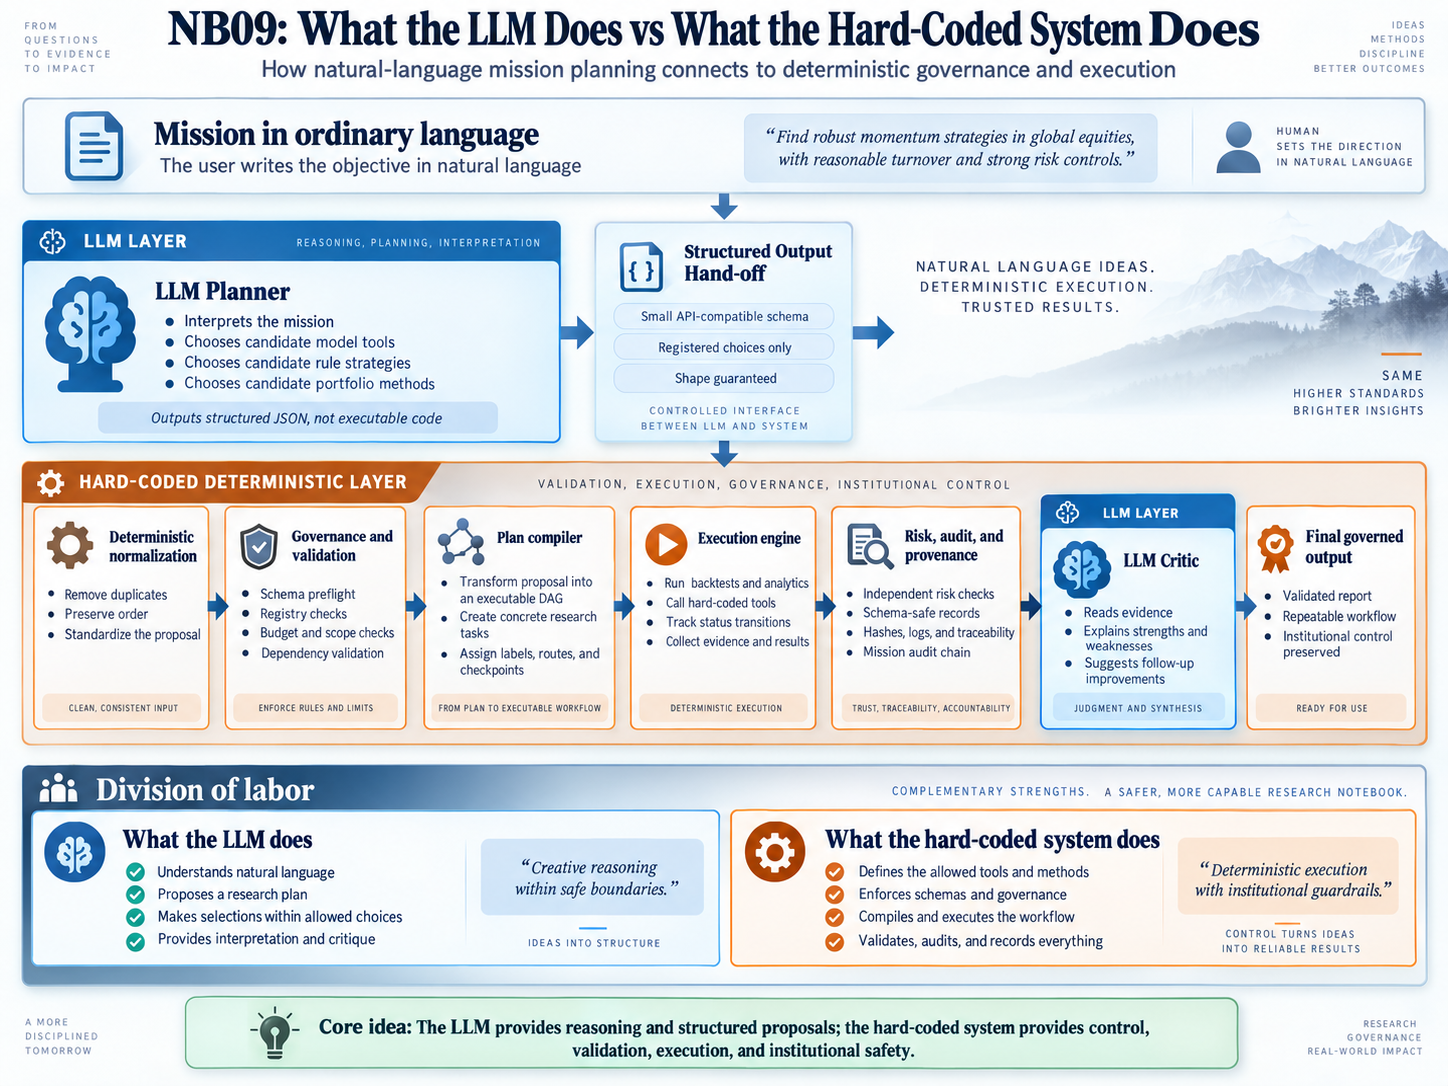


# What changed from NB08?

NB08 already had authentic quantitative execution. Logistic regression, KNN, random forest, a bounded MLP, and linear regression were real estimators; strategies and portfolios were actually calculated; cost stresses were real; and the mission state machine was real. The missing layer was cognitive interpretation.

In NB08, `interpret_mission`, `discover_model_tools`, and `build_dynamic_plan` were deterministic Python functions. They made decisions through field checks, keyword matching, fixed aliases, and predeclared branching policies. That was a valid bounded autonomous controller, but it was not an LLM agent.

NB09 changes the ontology of the control plane. A language model now reads an ordinary research objective and returns a structured experimental proposal. It can recognize semantic equivalence that keyword matching would miss, decide that a broad robustness question needs diversified model families, distinguish a narrow KNN question from a general model-selection question, and articulate assumptions or unresolved questions. The proposal is then compiled into the same type of governed executable graph that NB08 already knew how to run.

The crucial architectural point is that **the LLM does not replace the institution**. It occupies one bounded role inside it. The policy gate exists before the LLM. Registry validation exists after the LLM. Mathematical tools remain deterministic. Champion selection remains deterministic. Risk remains independent. Material decisions remain human.

That distinction is what turns an LLM from a clever chatbot into a component of an autonomous quantitative research system.


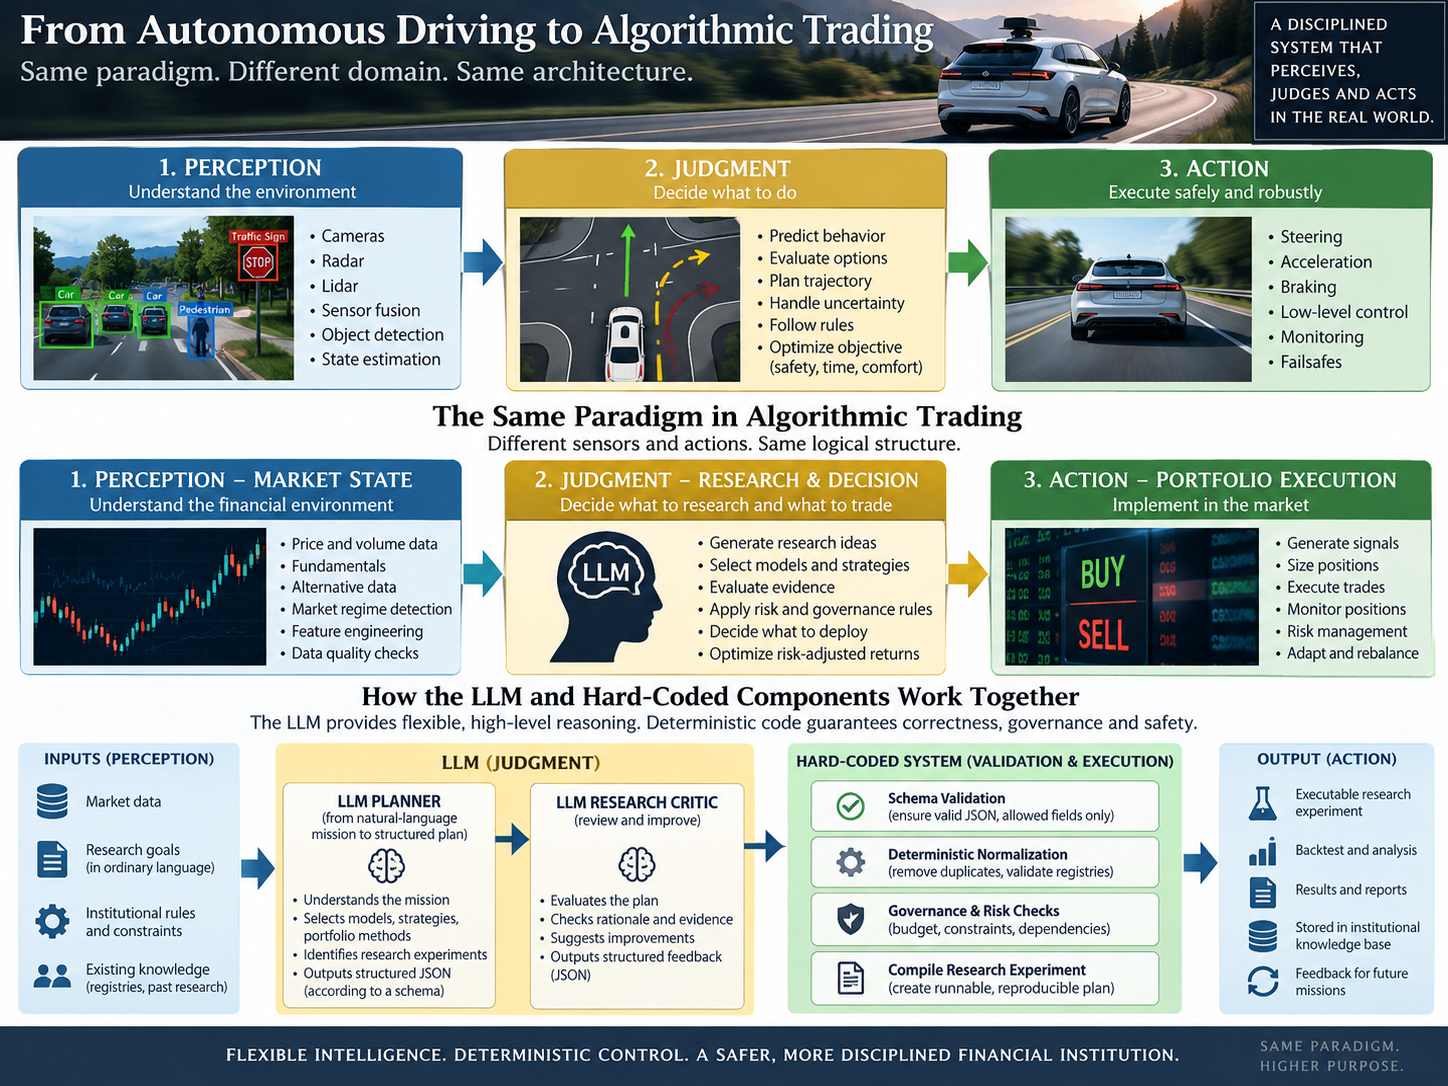

## Conclusion

NB09 marks a pivotal advancement in the development of an autonomous quantitative research system by integrating a language model (LLM) as a bounded cognitive control plane. This iteration successfully closes the gap left by previous deterministic orchestrations, introducing an LLM that can interpret natural-language research objectives, select from pre-approved model tools, choose rule-based strategies, and explain its proposed research design. Crucially, the LLM's role is precisely defined and constrained: it acts as a sophisticated planner and critic, not as an authority in calculation, deployment, or decision-making.

The architecture maintains a clear separation of concerns, ensuring that the LLM is responsible for interpretation, planning, synthesis, and challenge, while deterministic quantitative tools handle estimation, prediction, backtesting, and portfolio mathematics. A robust policy layer enforces authority, permissions, and limits, and human oversight remains paramount for all material decisions. This fundamental separation is evident in the execution chain, which features a hard admission gate that scrutinizes missions before any LLM involvement, preventing the LLM from circumventing institutional boundaries or advocating for prohibited actions like live trading or self-approval.

Furthermore, the system incorporates an independent risk review and a second LLM as a research critic. After the quantitative experiments are conducted and a research champion is mathematically selected, the critic LLM evaluates the results, identifies weaknesses, and proposes follow-up experiments, but it cannot promote a strategy. This multi-layered governance—involving a pre-LLM admission gate, a post-LLM compilation into executable DAGs, deterministic quantitative execution, and independent LLM-powered critique—creates a highly robust and auditable research environment.

All LLM interactions are captured as first-class provenance objects, complete with model identity, response IDs, prompt versions, token usage, and cryptographic hashes of inputs and outputs. This comprehensive audit trail ensures transparency and accountability throughout the research lifecycle, transforming the LLM from a mere chatbot into an integral, yet carefully controlled, component of a sophisticated autonomous research framework. NB09 demonstrates that powerful LLM capabilities can be harnessed safely and effectively within a governed institutional context, paving the way for more intelligent and efficient quantitative research while maintaining critical human and policy safeguards.